In [3]:
import torch
import torch.nn as nn
import itertools 
import numpy as np 
import math
import scipy 
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)
import torch.nn.functional as F


ZERO = torch.tensor(0.0).to(device) 
pi = torch.tensor(np.pi).to(device) 


tensor([  16.,   32.,   64.,  128.,  256.,  512., 1024., 2048.])
tensor([  27.,   64.,   64.,  216.,  343.,  512., 1331., 2197.])
tensor([  16.,   32.,   64.,  128.,  256.,  512., 1024., 2048.])
tensor([  27.,   64.,   64.,  216.,  343.,  512., 1331., 2197.])
tensor([  16.,   32.,   64.,  128.,  256.,  512., 1024., 2048.])
tensor([  27.,   64.,   64.,  216.,  343.,  512., 1331., 2197.])
tensor([  16.,   32.,   64.,  128.,  256.,  512., 1024., 2048.])
tensor([  27.,   64.,   64.,  216.,  343.,  512., 1331., 2197.])


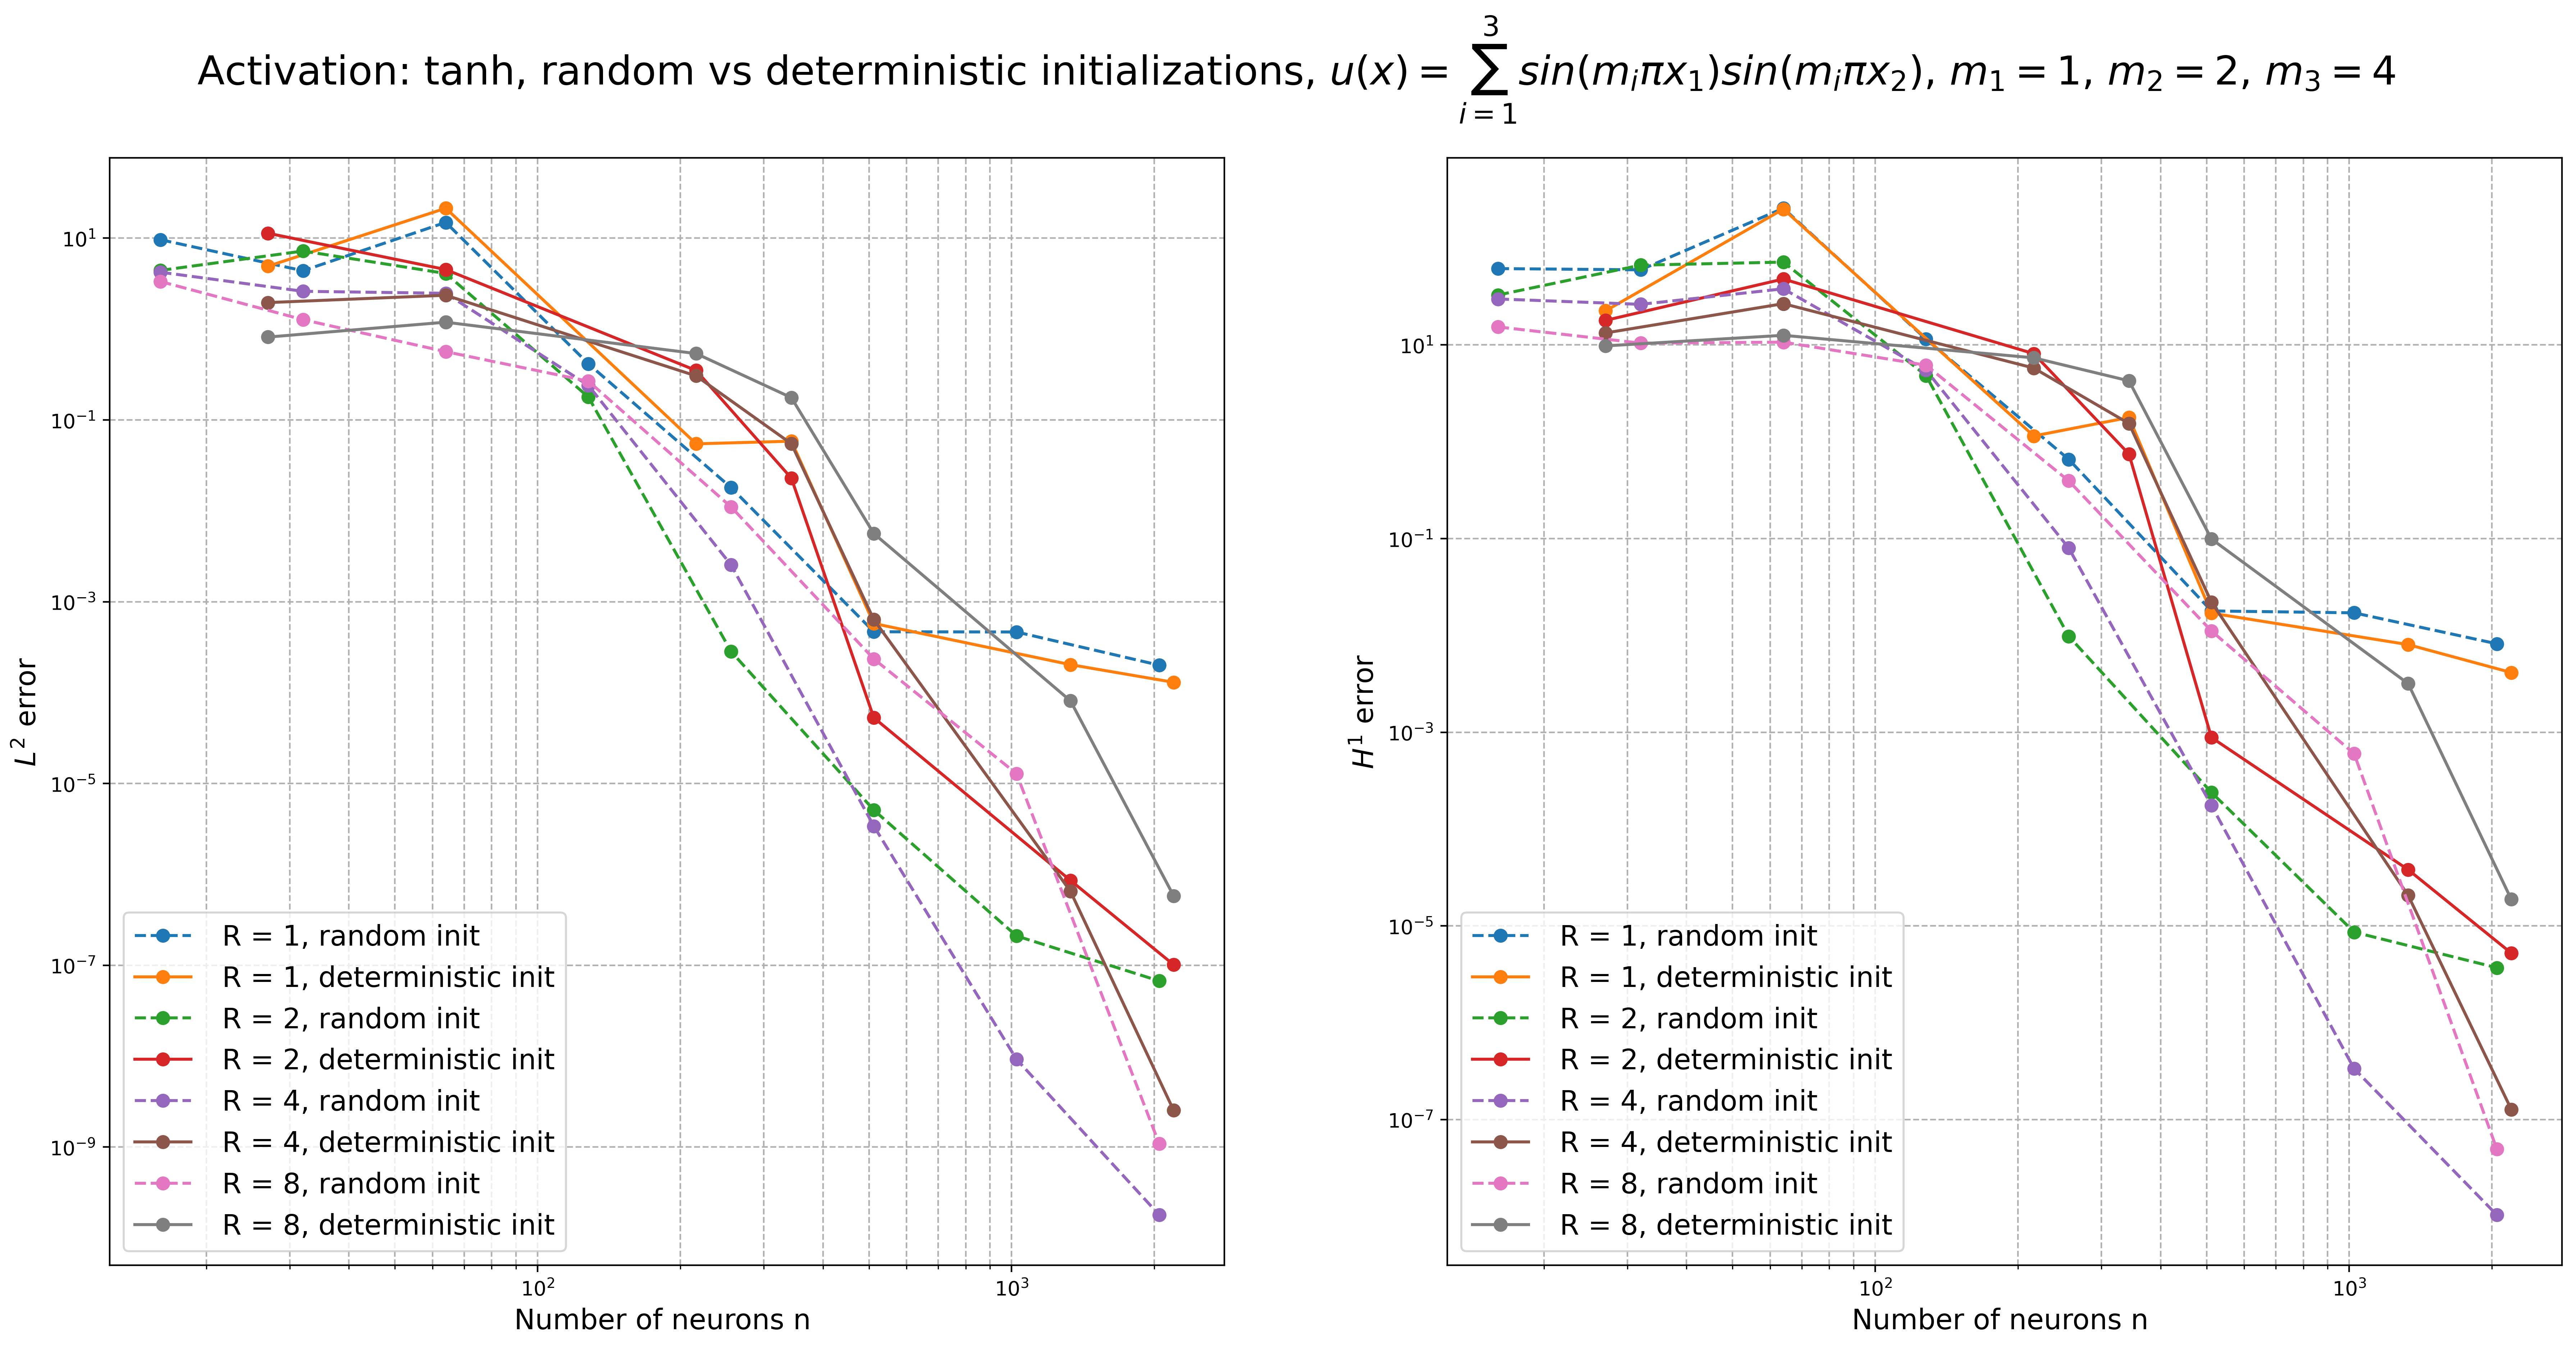

In [11]:
m1 = 1
m2 = 2
m3 = 4 
rand = True  # whether to use random initialization or deterministic one over [-R,R]
d = 2          # spatial dimension (you can change this to, say, 10)
input_dim = d # spatial
activation = 'tanh'
relu_k = 3 #if activation is tanh, this parameter is not used


# integration_weights, integration_points = PiecewiseGQ2D_weights_points(Nx,order,(-1,-1),(1,1))
x_l= 0
x_r = 1
fig, axes = plt.subplots(1, 2, figsize=(11*2, 10), dpi=400) 

for Rm in [1, 2,4,8]:
    err_l2_rand = torch.load("data-compare-rand/l2err_ELM_rand_True_2D_acttanh_R{}_m1_2_4.pt".format(Rm)).to(device)
    err_h1_rand = torch.load("data-compare-rand/H1err_ELM_rand_True_2D_acttanh_R{}_m1_2_4.pt".format(Rm)).to(device)
    neuron_list_rand = torch.load("data-compare-rand/neuronlist_ELM_rand_True_2D_acttanh_R{}_m1_2_4.pt".format(Rm)).to(device)

    err_l2_deter = torch.load("data-compare-rand/l2err_ELM_rand_False_2D_acttanh_R{}_m1_2_4.pt".format(Rm)).to(device)
    err_h1_deter = torch.load("data-compare-rand/H1err_ELM_rand_False_2D_acttanh_R{}_m1_2_4.pt".format(Rm)).to(device)
    neuron_list_deter = torch.load("data-compare-rand/neuronlist_ELM_rand_False_2D_acttanh_R{}_m1_2_4.pt".format(Rm)).to(device)
    print(neuron_list_rand)
    print(neuron_list_deter)

    axes[0].loglog(neuron_list_rand, err_l2_rand, 'o--', label=f' R = {Rm}, random init')
    axes[0].loglog(neuron_list_deter, err_l2_deter, 'o-', label=f' R = {Rm}, deterministic init')
    axes[0].set_xlabel('Number of neurons n ',fontsize=14)
    axes[0].set_ylabel('$L^2$ error',fontsize=14)
    axes[0].grid(True, which="both", ls="--")   

    axes[1].loglog(neuron_list_rand, err_h1_rand, 'o--', label=f' R = {Rm}, random init')
    axes[1].loglog(neuron_list_deter, err_h1_deter, 'o-', label=f' R = {Rm}, deterministic init')
    axes[1].set_xlabel('Number of neurons n ',fontsize=14)
    axes[1].set_ylabel('$H^1$ error',fontsize=14)
    axes[1].grid(True, which="both", ls="--")
    axes[0].legend(fontsize=14)
    axes[1].legend(fontsize=14)
plt.suptitle(f'Activation: {activation}, random vs deterministic initializations, $u(x) = \sum_{{i=1}}^{3} sin(m_i \pi x_1)sin(m_i \pi x_2)$, $m_1={m1}$, $m_2={m2}$, $m_3={m3}$', fontsize=20)
# plt.savefig('figures/compare_rand_d{}_act{}_m{}_{}_{}.png'.format(d,activation,m1,m2,m3), bbox_inches='tight')
plt.show()
